In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ===============================
# Save Preprocessing Artifacts
# ===============================

import pickle
import os


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
plt.style.use("seaborn-v0_8")

Load NASA C-MAPSS FD001 Dataset

In [2]:
def load_data(path="train_FD001.txt"):
    columns = (
        ['engine_id','cycle'] +
        ['setting1','setting2','setting3'] +
        [f'sensor{i}' for i in range(1,22)]
    )
    df = pd.read_csv(path, sep=" ", header=None)
    df.dropna(axis=1, inplace=True)
    df.columns = columns
    return df

train_df = load_data()
train_df.head()

,engine_id,cycle,setting1,setting2,setting3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor12,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


RUL Engineering (Capped + Normalized)

In [3]:
RUL_CAP = 125

def compute_rul(df, cap=125):
    max_cycles = df.groupby("engine_id")["cycle"].max()
    df["RUL_raw"] = df.apply(
        lambda r: max_cycles[r.engine_id] - r.cycle, axis=1
    )
    df["RUL"] = df["RUL_raw"].clip(upper=cap)
    df["RUL_norm"] = df["RUL"] / cap
    return df

train_df = compute_rul(train_df)
train_df[["engine_id","cycle","RUL_raw","RUL","RUL_norm"]].head()

,engine_id,cycle,RUL_raw,RUL,RUL_norm
0,1,1,191.0,125.0,1.0
1,1,2,190.0,125.0,1.0
2,1,3,189.0,125.0,1.0
3,1,4,188.0,125.0,1.0
4,1,5,187.0,125.0,1.0


Feature Selection & Scaling

In [4]:
def select_and_scale_features(df, threshold=0.01):
    sensor_cols = [f"sensor{i}" for i in range(1,22)]
    selected = df[sensor_cols].std()[df[sensor_cols].std() > threshold].index.tolist()
    
    scaler = MinMaxScaler()
    df[selected] = scaler.fit_transform(df[selected])
    
    return df, selected, scaler

train_df, features, scaler = select_and_scale_features(train_df)

print("Number of selected sensors:", len(features))
features

Number of selected sensors: 14


['sensor2',
 'sensor3',
 'sensor4',
 'sensor7',
 'sensor8',
 'sensor9',
 'sensor11',
 'sensor12',
 'sensor13',
 'sensor14',
 'sensor15',
 'sensor17',
 'sensor20',
 'sensor21']

Sequence Generation

In [5]:
def create_sequences(df, features, seq_len=30):
    X, y = [], []

    for eid in df["engine_id"].unique():
        edf = df[df["engine_id"] == eid]
        data = edf[features].values
        rul = edf["RUL_norm"].values

        for i in range(len(data) - seq_len):
            X.append(data[i:i+seq_len])
            y.append(rul[i+seq_len])

    return np.array(X), np.array(y)

SEQ_LEN = 30
X, y = create_sequences(train_df, features, SEQ_LEN)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (17631, 30, 14)
y shape: (17631,)


Train / Validation Split

In [6]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Build LSTM Model (Reusable)

In [7]:
def build_lstm(input_shape):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(64),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

model = build_lstm((SEQ_LEN, X.shape[2]))
model.summary()

c:\Users\aksha\miniconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        20,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,313 (208.25 KB)

 Trainable params: 53,313 (208.25 KB)

 Non-trainable params: 0 (0.00 B)

Train Model

In [8]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=8,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/8
221/221 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.0407 - val_loss: 0.0192
Epoch 2/8
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0188 - val_loss: 0.0152
Epoch 3/8
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0152 - val_loss: 0.0145
Epoch 4/8
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0140 - val_loss: 0.0159
Epoch 5/8
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0139 - val_loss: 0.0138
Epoch 6/8
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.0132 - val_loss: 0.0136
Epoch 7/8
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.0132 - val_loss: 0.0128
Epoch 8/8
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0125 - val_loss: 0.0153


Training Curve Visualization

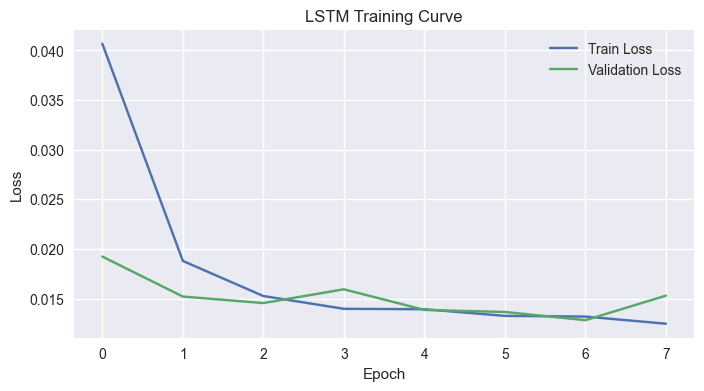

In [9]:
plt.figure(figsize=(8,4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Training Curve")
plt.legend()
plt.show()


111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


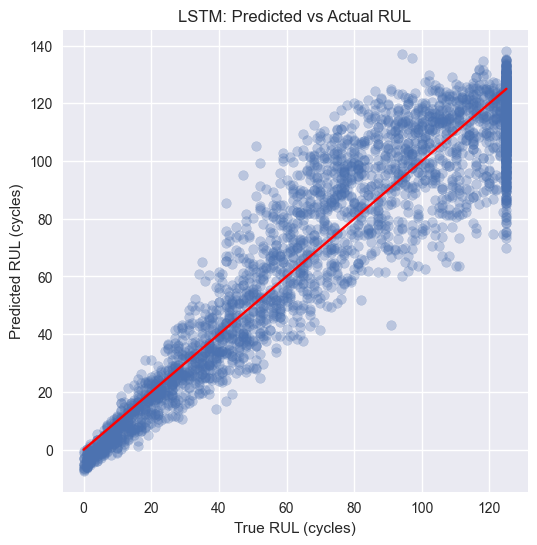

In [10]:
y_pred = model.predict(X_val).flatten()

y_val_denorm = y_val * RUL_CAP
y_pred_denorm = y_pred * RUL_CAP

plt.figure(figsize=(6,6))
plt.scatter(y_val_denorm, y_pred_denorm, alpha=0.3)
plt.plot([0, RUL_CAP], [0, RUL_CAP], 'r')
plt.xlabel("True RUL (cycles)")
plt.ylabel("Predicted RUL (cycles)")
plt.title("LSTM: Predicted vs Actual RUL")
plt.show()


Residual Error Distribution

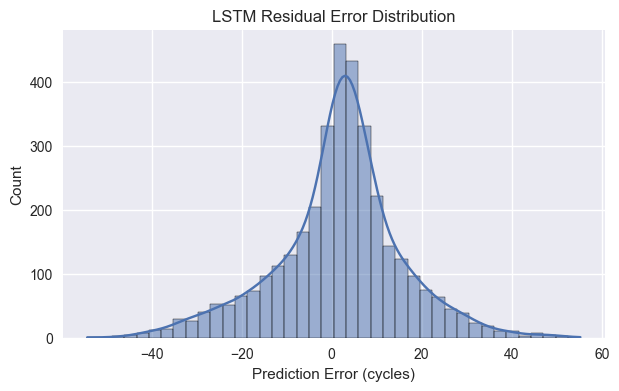

In [11]:
residuals = y_val_denorm - y_pred_denorm

plt.figure(figsize=(7,4))
sns.histplot(residuals, bins=40, kde=True)
plt.xlabel("Prediction Error (cycles)")
plt.title("LSTM Residual Error Distribution")
plt.show()

Line Plot for a Single Engine

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


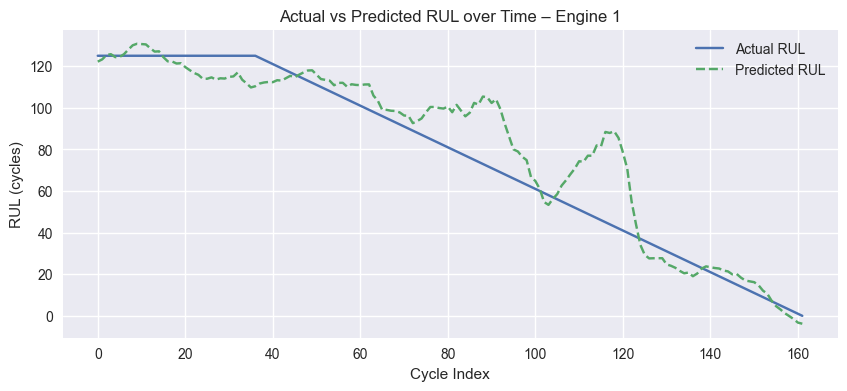

In [12]:
def plot_rul_over_cycles(engine_id, df, model, features, seq_len=30):
    engine_df = df[df.engine_id == engine_id].copy()

    if len(engine_df) <= seq_len:
        print("Not enough cycles for this engine")
        return

    X_engine, y_engine = create_sequences(engine_df, features, seq_len)

    y_pred = model.predict(X_engine).flatten() * RUL_CAP
    y_true = y_engine * RUL_CAP

    plt.figure(figsize=(10,4))
    plt.plot(y_true, label="Actual RUL")
    plt.plot(y_pred, label="Predicted RUL", linestyle="--")
    plt.xlabel("Cycle Index")
    plt.ylabel("RUL (cycles)")
    plt.title(f"Actual vs Predicted RUL over Time – Engine {engine_id}")
    plt.legend()
    plt.show()


# Example
plot_rul_over_cycles(engine_id=1, df=train_df, model=model, features=features)


Numerical Metrics (FOR COMPARISON)

In [13]:
metrics_lstm = {
    "RMSE": np.sqrt(mean_squared_error(y_val, y_pred)),
    "MAE": mean_absolute_error(y_val, y_pred),
    "R2": r2_score(y_val, y_pred)
}

metrics_lstm

{'RMSE': np.float64(0.11320975496075293),
 'MAE': 0.08366474368851415,
 'R2': 0.8858840865232466}

ENGINE DEGRADATION VISUALIZATION

Engine rows: (192, 29)
Using features: ['sensor2', 'sensor3', 'sensor4']


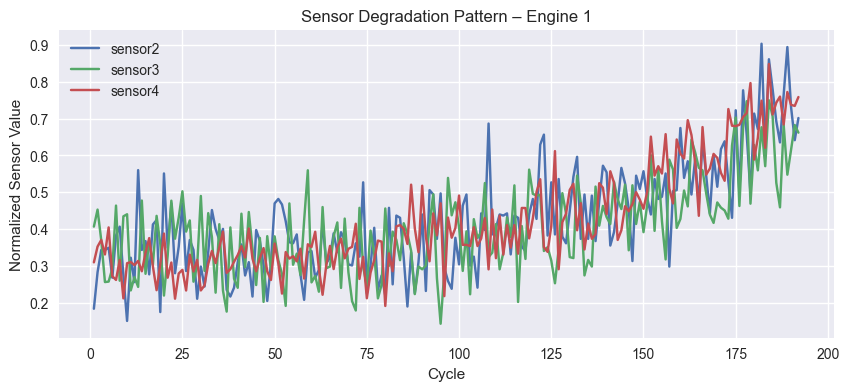

In [14]:
def plot_engine_degradation(engine_id, df, features):
    engine_id = int(engine_id)
    engine_df = df[df["engine_id"] == engine_id]

    print("Engine rows:", engine_df.shape)
    print("Using features:", features[:3])

    if engine_df.empty:
        print("❌ No data found for this engine ID")
        return

    plt.figure(figsize=(10,4))
    for f in features[:3]:
        plt.plot(engine_df["cycle"], engine_df[f], label=f)

    plt.title(f"Sensor Degradation Pattern – Engine {engine_id}")
    plt.xlabel("Cycle")
    plt.ylabel("Normalized Sensor Value")
    plt.legend()
    plt.show()


plot_engine_degradation(1, train_df, features)


Feature Importance via Correlation

In [15]:
# Compute absolute correlation with RUL
corr_values = train_df[features].corrwith(train_df["RUL"]).abs()

feature_importance_corr = (
    corr_values
    .sort_values(ascending=False)
    .reset_index()
)

feature_importance_corr.columns = ["Feature", "Importance"]

feature_importance_corr.head(10)

,Feature,Importance
0,sensor11,0.775230
1,sensor4,0.757157
2,sensor12,0.748870
3,sensor7,0.733021
4,sensor15,0.720858
5,sensor21,0.707334
6,sensor20,0.704626
7,sensor17,0.680829
8,sensor2,0.678458
9,sensor3,0.655030


Top Feature Importance Plot (Correlation)

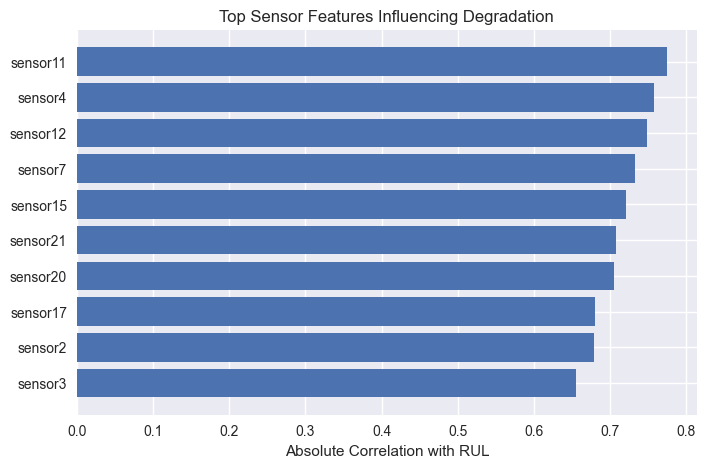

In [16]:
top_k = 10
top_features = feature_importance_corr.head(top_k)

plt.figure(figsize=(8,5))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Absolute Correlation with RUL")
plt.title("Top Sensor Features Influencing Degradation")
plt.show()

PERMUTATION IMPORTANCE

In [17]:

def permutation_importance_dl(
    model, X_val, y_val, features, n_repeats=3
):
    baseline_loss = model.evaluate(X_val, y_val, verbose=0)
    importances = {}

    for idx, feature in enumerate(features):
        losses = []

        for _ in range(n_repeats):
            X_permuted = X_val.copy()
            np.random.shuffle(X_permuted[:, :, idx])
            loss = model.evaluate(X_permuted, y_val, verbose=0)
            losses.append(loss)

        importances[feature] = np.mean(losses) - baseline_loss

    return importances


# Run permutation importance (LIMIT FEATURES IF NEEDED)
perm_importance = permutation_importance_dl(
    model,
    X_val,
    y_val,
    features[:10],   # limit for speed
    n_repeats=3
)

perm_df = (
    pd.DataFrame.from_dict(perm_importance, orient="index", columns=["Importance"])
    .sort_values("Importance", ascending=False)
)

perm_df

,Importance
sensor9,0.004977
sensor12,0.004311
sensor7,0.004259
sensor11,0.003485
sensor4,0.002640
sensor14,0.002357
sensor2,0.002069
sensor8,0.001318
sensor13,0.001310
sensor3,0.000065


Top Feature Importance Plot

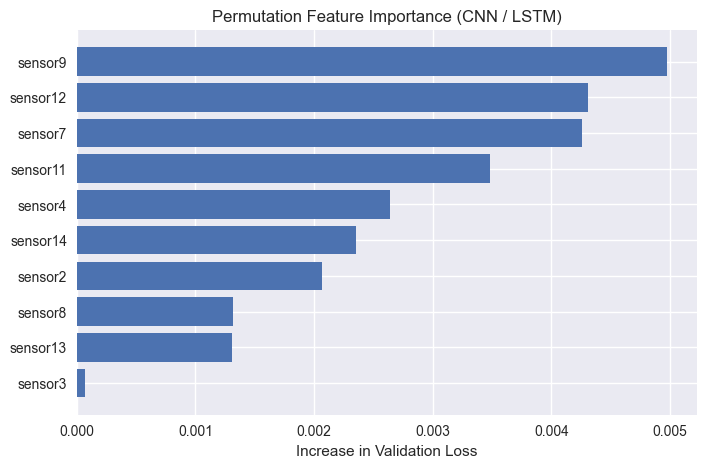

In [18]:
plt.figure(figsize=(8,5))
plt.barh(perm_df.index, perm_df["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Increase in Validation Loss")
plt.title("Permutation Feature Importance (CNN / LSTM)")
plt.show()

In [19]:
import os
import pickle

BASE_DIR = os.getcwd()   # notebook execution directory
MODEL_DIR = os.path.join(BASE_DIR, "model")

os.makedirs(MODEL_DIR, exist_ok=True)

with open(os.path.join(MODEL_DIR, "scaler.pkl"), "wb") as f:
    pickle.dump(scaler, f)

with open(os.path.join(MODEL_DIR, "features.pkl"), "wb") as f:
    pickle.dump(features, f)

print("Saved files in:", MODEL_DIR)
print(os.listdir(MODEL_DIR))


Saved files in: d:\BIA Capstine LSTM (Turbofan Data)\Project111\Project\model
['features.pkl', 'lstm_rul_deployment.keras', 'metadata.pkl', 'scaler.pkl']


Save Model for Website Deployment

In [20]:
model.save("lstm_rul_deployment.h5")
print("✅ LSTM model saved for Django deployment")

✅ LSTM model saved for Django deployment


In [21]:
import os
os.makedirs("model", exist_ok=True)

model.save("model/lstm_rul_deployment.keras")
print("✅ Model saved inside model/ directory")


✅ Model saved inside model/ directory


In [22]:
# ===============================
# Create model directory
# ===============================

os.makedirs("model", exist_ok=True)
    

In [23]:
# ===============================
# Save scaler
# ===============================

with open("model/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("✅ scaler.pkl saved")


✅ scaler.pkl saved


In [24]:
# ===============================
# Save selected features
# ===============================

with open("model/features.pkl", "wb") as f:
    pickle.dump(features, f)

print("✅ features.pkl saved")


✅ features.pkl saved


In [25]:
# ===============================
# Save metadata (optional)
# ===============================

metadata = {
    "seq_len": SEQ_LEN,
    "rul_cap": RUL_CAP,
    "num_features": len(features)
}

with open("model/metadata.pkl", "wb") as f:
    pickle.dump(metadata, f)

print("✅ metadata.pkl saved")


✅ metadata.pkl saved


In [26]:
import os
print("Current working directory:")
print(os.getcwd())

print("\nFiles here:")
print(os.listdir())

Current working directory:
d:\BIA Capstine LSTM (Turbofan Data)\Project111\Project

Files here:
['app.py', 'app1.py', 'CNN_RUL_MODULAR_FINAL.ipynb', 'EDA.ipynb', 'FINAL_MODEL_COMPARISON.ipynb', 'flask_app.py', 'lstm_rul_deployment.h5', 'LSTM_RUL_Modular.ipynb', 'model', 'rag', 'RandomForest_RUL_MODULAR_FINAL.ipynb', 'RUL_FD001.txt', 'static', 'templates', 'test_FD001.txt', 'test_rag.py', 'train_FD001.txt', 'XGBoost_RUL_MODULAR_FINAL.ipynb']


In [27]:
# ===============================
# Verify saved artifacts
# ===============================

os.listdir("model")


['features.pkl', 'lstm_rul_deployment.keras', 'metadata.pkl', 'scaler.pkl']

In [28]:
['lstm_rul_deployment.h5',
 'scaler.pkl',
 'features.pkl',
 'metadata.pkl']


['lstm_rul_deployment.h5', 'scaler.pkl', 'features.pkl', 'metadata.pkl']